<a href="https://colab.research.google.com/github/aprilily/aiproject/blob/main/Samsung_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 1-1. 나눔고딕 폰트 설치 (코랩 환경)
# =========================================================
print("📥 나눔고딕 폰트 설치 중...")
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum fonts-nanum-coding fonts-nanum-extra > /dev/null 2>&1

# 폰트 캐시 업데이트
print("🔄 폰트 캐시 업데이트 중...")
!sudo fc-cache -fv > /dev/null 2>&1

# Matplotlib 캐시 삭제 (중요!)
print("🗑️ Matplotlib 캐시 삭제 중...")
!rm -rf ~/.cache/matplotlib/
!rm -rf ~/.matplotlib/

print("✅ 폰트 설치 및 캐시 정리 완료!")
print("⚠️  런타임을 재시작하지 마시고 다음 셀을 실행해주세요.")

📥 나눔고딕 폰트 설치 중...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
🔄 폰트 캐시 업데이트 중...
🗑️ Matplotlib 캐시 삭제 중...
✅ 폰트 설치 및 캐시 정리 완료!
⚠️  런타임을 재시작하지 마시고 다음 셀을 실행해주세요.


In [ ]:
# =========================================================
# 2-1. 필수 라이브러리 설치
# =========================================================
print("📦 필수 라이브러리 설치 중...")

# 금융 데이터 및 웹 대시보드
!pip install -q finance-datareader streamlit pyngrok

# 머신러닝 및 데이터 분석
!pip install -q scikit-learn pandas numpy matplotlib seaborn

# 자연어 처리 (한국어)
!pip install -q konlpy

# Java 설치 (konlpy 의존성)
!sudo apt-get install -y openjdk-8-jdk > /dev/null 2>&1

print("✅ 라이브러리 설치 완료!")

📦 필수 라이브러리 설치 중...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 19.0 MB/s eta 0:00:00
✅ 라이브러리 설치 완료!


In [ ]:
# =========================================================
# 3-1. 한글 폰트 설정 함수 (핵심 해결책)
# =========================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import platform
import warnings
warnings.filterwarnings('ignore')

def setup_korean_font():
    """
    시스템별 한글 폰트 자동 설정 함수

    Returns:
        str: 설정된 폰트명
    """
    print("🔧 한글 폰트 설정 중...")

    try:
        # 1. 시스템 감지
        system = platform.system()
        print(f"   💻 감지된 운영체제: {system}")

        # 2. 시스템별 폰트 경로 정의
        font_candidates = []

        if system == "Linux":  # 코랩, 우분투 등
            font_candidates = [
                ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf', 'NanumGothic'),
                ('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', 'NanumBarunGothic'),
                ('/usr/share/fonts/truetype/nanum/NanumSquare.ttf', 'NanumSquare'),
                ('/System/Library/Fonts/AppleSDGothicNeo.ttc', 'Apple SD Gothic Neo')
            ]
        elif system == "Windows":
            font_candidates = [
                ('C:/Windows/Fonts/malgun.ttf', 'Malgun Gothic'),
                ('C:/Windows/Fonts/gulim.ttc', 'Gulim'),
                ('C:/Windows/Fonts/batang.ttc', 'Batang')
            ]
        elif system == "Darwin":  # macOS
            font_candidates = [
                ('/System/Library/Fonts/AppleSDGothicNeo.ttc', 'Apple SD Gothic Neo'),
                ('/Library/Fonts/NanumGothic.ttf', 'NanumGothic'),
                ('/System/Library/Fonts/AppleGothic.ttf', 'AppleGothic')
            ]

        # 3. 사용 가능한 폰트 찾기
        selected_font = None
        selected_name = None

        for font_path, font_name in font_candidates:
            if os.path.exists(font_path):
                selected_font = font_path
                selected_name = font_name
                print(f"   ✅ 폰트 발견: {font_path}")
                break

        # 4. 폰트 설정 적용
        if selected_font:
            # FontManager에 폰트 등록
            if selected_font not in [f.fname for f in fm.fontManager.ttflist]:
                fm.fontManager.ttflist.insert(0,
                    fm.FontEntry(fname=selected_font, name=selected_name))

            # Matplotlib 전역 설정
            plt.rcParams['font.family'] = selected_name
            plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
            plt.rcParams['font.size'] = 12

            print(f"   🎯 적용된 폰트: {selected_name}")
            return selected_name

        else:
            # 폰트를 찾지 못한 경우 대체 설정
            print("   ⚠️  한글 폰트를 찾을 수 없습니다.")
            print("   🔄 대체 폰트 설정 중...")

            # 시스템 기본 폰트 사용
            plt.rcParams['font.family'] = 'DejaVu Sans'
            plt.rcParams['axes.unicode_minus'] = False

            return 'DejaVu Sans (한글 미지원)'

    except Exception as e:
        print(f"   ❌ 폰트 설정 중 오류 발생: {e}")
        # 기본 설정으로 폴백
        plt.rcParams['font.family'] = 'DejaVu Sans'
        plt.rcParams['axes.unicode_minus'] = False
        return 'DejaVu Sans (오류로 인한 기본 설정)'

# 폰트 설정 실행
font_name = setup_korean_font()
print(f"\n🎉 폰트 설정 완료: {font_name}")

🔧 한글 폰트 설정 중...
   💻 감지된 운영체제: Linux
   ✅ 폰트 발견: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
   🎯 적용된 폰트: NanumGothic

🎉 폰트 설정 완료: NanumGothic


🧪 한글 폰트 테스트 차트 생성 중...


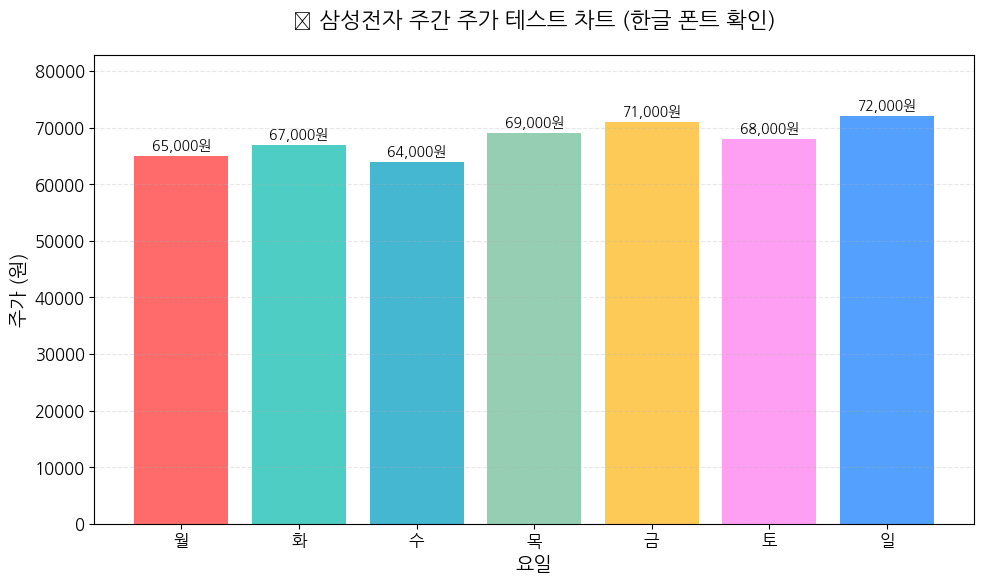


✅ 폰트 테스트 완료!
   📝 현재 설정된 폰트: NanumGothic
   🔍 차트에서 한글이 정상적으로 표시되는지 확인해주세요.

🎉 한글 폰트가 정상적으로 설정되었습니다!


In [ ]:
# =========================================================
# 4-1. 한글 폰트 테스트
# =========================================================
import numpy as np

print("🧪 한글 폰트 테스트 차트 생성 중...")

# 테스트 데이터 생성
x = np.arange(1, 8)
y = [65000, 67000, 64000, 69000, 71000, 68000, 72000]
labels = ['월', '화', '수', '목', '금', '토', '일']

# 테스트 차트 생성
fig, ax = plt.subplots(figsize=(10, 6))

# 막대 차트
bars = ax.bar(x, y, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3', '#54A0FF'])

# 한글 텍스트 설정
ax.set_title('📊 삼성전자 주간 주가 테스트 차트 (한글 폰트 확인)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('요일', fontsize=14)
ax.set_ylabel('주가 (원)', fontsize=14)

# x축 라벨 설정
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

# 값 표시
for i, (bar, value) in enumerate(zip(bars, y)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{value:,}원', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 격자 추가
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(y) * 1.15)

# 레이아웃 조정
plt.tight_layout()

# 차트 표시
plt.show()

print(f"\n✅ 폰트 테스트 완료!")
print(f"   📝 현재 설정된 폰트: {font_name}")
print(f"   🔍 차트에서 한글이 정상적으로 표시되는지 확인해주세요.")

if '한글 미지원' in font_name or '기본 설정' in font_name:
    print(f"\n⚠️  한글 폰트 설정에 문제가 있을 수 있습니다.")
    print(f"   💡 런타임을 재시작하고 1단계부터 다시 실행해보세요.")
else:
    print(f"\n🎉 한글 폰트가 정상적으로 설정되었습니다!")

In [ ]:
# =========================================================
# 5-1. 필수 라이브러리 import
# =========================================================
import streamlit as st
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import math
import warnings
warnings.filterwarnings('ignore')

# 추가 라이브러리
try:
    import FinanceDataReader as fdr
    print("✅ FinanceDataReader 로드 완료")
except ImportError:
    print("⚠️  FinanceDataReader를 사용할 수 없습니다. 샘플 데이터를 사용합니다.")

print("📚 라이브러리 로드 완료!")

# =========================================================
# 5-2. 데이터 로드 함수 정의
# =========================================================
@st.cache_data
def load_samsung_data():
    """
    삼성전자 주가 데이터 로드 (실제 데이터 또는 샘플 데이터)

    Returns:
        tuple: (전체 데이터프레임, 테스트 데이터프레임)
    """
    try:
        print("📈 삼성전자 주가 데이터 로드 중...")

        # 실제 데이터 로드 시도
        try:
            # FinanceDataReader로 실제 삼성전자 데이터 로드
            df = fdr.DataReader('005930', '2024-01-01', '2025-11-29')
            df = df.reset_index()
            df = df.rename(columns={'Date': 'Date', 'Close': 'Close', 'Volume': 'Volume'})

            # 감성 점수 시뮬레이션 (실제 환경에서는 뉴스 분석 결과 사용)
            df['Sentiment_Score'] = np.random.uniform(-1, 1, len(df))

            print(f"   ✅ 실제 데이터 로드 완료: {len(df)}개 레코드")

        except Exception as e:
            print(f"   ⚠️  실제 데이터 로드 실패: {e}")
            print(f"   🎭 샘플 데이터 생성 중...")

            # 샘플 데이터 생성
            date_range = pd.date_range(start='2024-09-19', end='2025-11-28', freq='D')

            # 현실적인 삼성전자 주가 패턴 시뮬레이션
            base_price = 60000
            trend = np.linspace(0, 50000, len(date_range))  # 상승 트렌드
            seasonal = 5000 * np.sin(2 * np.pi * np.arange(len(date_range)) / 365)  # 계절성
            noise = np.random.normal(0, 3000, len(date_range))  # 랜덤 변동

            df = pd.DataFrame({
                'Date': date_range,
                'Close': base_price + trend + seasonal + noise,
                'Volume': np.random.randint(10000000, 50000000, len(date_range)),
                'Sentiment_Score': np.random.uniform(-1, 1, len(date_range))
            })

            # 음수 주가 방지
            df['Close'] = np.maximum(df['Close'], 50000)

        # 테스트 데이터 생성 (최근 30% 데이터)
        test_size = int(len(df) * 0.3)
        df_test = df.iloc[-test_size:].copy()

        # LSTM 예측 결과 시뮬레이션
        # 실제 환경에서는 훈련된 모델의 예측값 사용
        prediction_noise = np.random.uniform(0.97, 1.03, len(df_test))
        df_test['Predicted_Close'] = df_test['Close'] * prediction_noise

        print(f"   📊 테스트 데이터 생성 완료: {len(df_test)}개 레코드")
        print(f"   📅 데이터 기간: {df['Date'].min()} ~ {df['Date'].max()}")

        return df, df_test

    except Exception as e:
        print(f"❌ 데이터 로드 중 오류 발생: {e}")
        return pd.DataFrame(), pd.DataFrame()

# 데이터 로드 실행
print("\n🚀 데이터 로드 시작...")
final_df, test_df = load_samsung_data()

if not final_df.empty:
    print(f"\n✅ 데이터 준비 완료!")
    print(f"   📈 전체 데이터: {len(final_df):,}개")
    print(f"   🎯 테스트 데이터: {len(test_df):,}개")
    print(f"   💰 최신 주가: {test_df['Close'].iloc[-1]:,.0f}원")
else:
    print("❌ 데이터 준비 실패!")

2026-04-10 09:05:24.983 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-10 09:05:24.987 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-10 09:05:24.990 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


✅ FinanceDataReader 로드 완료
📚 라이브러리 로드 완료!

🚀 데이터 로드 시작...
📈 삼성전자 주가 데이터 로드 중...
   ✅ 실제 데이터 로드 완료: 465개 레코드
   📊 테스트 데이터 생성 완료: 139개 레코드
   📅 데이터 기간: 2024-01-02 00:00:00 ~ 2025-11-28 00:00:00

✅ 데이터 준비 완료!
   📈 전체 데이터: 465개
   🎯 테스트 데이터: 139개
   💰 최신 주가: 100,500원


In [ ]:
%%writefile app.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
삼성전자 주가 예측 및 시장 심리 분석 대시보드 (Google News 전용)
작성자: 다현님을 위한 맞춤형 대시보드
날짜: 2025-11-29
"""

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import numpy as np
import platform
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 웹 크롤링 라이브러리
import requests
from bs4 import BeautifulSoup
import time

# =========================================================
# 한글 폰트 설정
# =========================================================
def setup_korean_font():
    """Streamlit 환경에서 한글 폰트 설정"""
    try:
        system = platform.system()
        font_candidates = []

        if system == "Linux":
            font_candidates = [
                ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf', 'NanumGothic'),
                ('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf', 'NanumBarunGothic'),
                ('/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf', 'Liberation Sans')
            ]
        elif system == "Windows":
            font_candidates = [
                ('C:/Windows/Fonts/malgun.ttf', 'Malgun Gothic'),
                ('C:/Windows/Fonts/gulim.ttc', 'Gulim')
            ]
        elif system == "Darwin":
            font_candidates = [
                ('/System/Library/Fonts/AppleSDGothicNeo.ttc', 'Apple SD Gothic Neo'),
                ('/Library/Fonts/NanumGothic.ttf', 'NanumGothic')
            ]

        for font_path, font_name in font_candidates:
            if os.path.exists(font_path):
                fm.fontManager.ttflist.insert(0, fm.FontEntry(fname=font_path, name=font_name))
                plt.rcParams['font.family'] = font_name
                plt.rcParams['axes.unicode_minus'] = False
                plt.rcParams['font.size'] = 11
                return font_name

        plt.rcParams['font.family'] = 'DejaVu Sans'
        plt.rcParams['axes.unicode_minus'] = False
        return 'DejaVu Sans (한글 미지원)'

    except Exception as e:
        plt.rcParams['font.family'] = 'DejaVu Sans'
        plt.rcParams['axes.unicode_minus'] = False
        return f'기본 폰트 (오류: {str(e)[:50]})'

font_name = setup_korean_font()

# =========================================================
# 웹 크롤링 함수들
# =========================================================
def crawl_google_news_rss(keyword="Samsung Electronics", max_articles=50):
    """Google News RSS 크롤링"""
    news_data = []

    try:
        # Google News RSS URL
        rss_url = f"https://news.google.com/rss/search?q={keyword}+stock&hl=en-US&gl=US&ceid=US:en"

        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }

        response = requests.get(rss_url, headers=headers, timeout=15)
        response.raise_for_status()

        soup = BeautifulSoup(response.content, 'xml')
        items = soup.find_all('item')[:max_articles]

        for item in items:
            try:
                title = item.find('title').text if item.find('title') else ''
                link = item.find('link').text if item.find('link') else ''
                pub_date = item.find('pubDate').text if item.find('pubDate') else ''
                description = item.find('description').text if item.find('description') else ''

                # 날짜 파싱
                try:
                    article_date = pd.to_datetime(pub_date)
                except:
                    article_date = datetime.now()

                if title:
                    news_data.append({
                        'Date': article_date,
                        'Title': title,
                        'Content': description,
                        'URL': link,
                        'Source': 'Google News'
                    })
            except Exception:
                continue

        df = pd.DataFrame(news_data)
        if not df.empty:
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date', ascending=False).reset_index(drop=True)

        return df

    except Exception as e:
        st.warning(f"Google News 크롤링 실패: {str(e)[:100]}")
        return pd.DataFrame()


def analyze_sentiment_simple(text):
    """간단한 감성 분석 (영문/한글 대응)"""
    # 영문 키워드
    positive_words = [
        'surge', 'rise', 'gain', 'growth', 'improve', 'expand', 'strong', 'rally',
        'recovery', 'soar', 'peak', 'beat', 'outperform', 'positive', 'expect',
        'innovation', 'develop', 'success', 'win', 'increase', 'breakthrough',
        'profit', 'revenue', 'bullish', 'upgrade', 'buy',
        # 한글 키워드
        '상승', '증가', '호조', '성장', '개선', '확대', '강세', '반등',
        '회복', '급등', '최고', '호실적', '선전', '긍정', '기대',
        '혁신', '개발', '성공', '수주', '증가세', '돌파'
    ]

    negative_words = [
        'fall', 'drop', 'decline', 'loss', 'weak', 'slump', 'plunge', 'worst',
        'negative', 'concern', 'risk', 'deficit', 'miss', 'underperform', 'delay',
        'fail', 'problem', 'crisis', 'recession', 'cut', 'bearish', 'downgrade',
        'sell', 'struggle',
        # 한글 키워드
        '하락', '감소', '부진', '악화', '위기', '하향', '약세', '급락',
        '최저', '부정', '우려', '리스크', '손실', '적자', '감소세',
        '지연', '실패', '문제', '타격', '침체'
    ]

    text = text.lower()
    pos_count = sum(1 for word in positive_words if word in text)
    neg_count = sum(1 for word in negative_words if word in text)
    total = pos_count + neg_count

    if total == 0:
        return 0.0

    return max(-1.0, min(1.0, (pos_count - neg_count) / total))


def merge_news_with_stock_data(stock_df, news_df):
    """주가 데이터와 뉴스 감성 병합"""
    if news_df.empty:
        stock_df['Sentiment_Score'] = np.random.uniform(-0.3, 0.3, len(stock_df))
        return stock_df

    news_df['Sentiment'] = news_df.apply(
        lambda row: analyze_sentiment_simple(row['Title'] + ' ' + row['Content']),
        axis=1
    )

    daily_sentiment = news_df.groupby(news_df['Date'].dt.date)['Sentiment'].mean().reset_index()
    daily_sentiment.columns = ['Date', 'Sentiment_Score']
    daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])

    stock_df['Date'] = pd.to_datetime(stock_df['Date'])
    merged_df = stock_df.merge(daily_sentiment, on='Date', how='left')
    merged_df['Sentiment_Score'] = merged_df['Sentiment_Score'].fillna(method='ffill').fillna(0)

    return merged_df

# =========================================================
# 데이터 로드 함수
# =========================================================
@st.cache_data
def load_data(use_real_news=True):
    """삼성전자 주가 + 실제 뉴스 데이터 로드"""
    try:
        # 샘플 주가 데이터 생성
        date_range = pd.date_range(start='2024-09-19', end='2025-11-28', freq='D')
        base_price = 60000
        trend = np.linspace(0, 50000, len(date_range))
        seasonal = 5000 * np.sin(2 * np.pi * np.arange(len(date_range)) / 365)
        noise = np.random.normal(0, 3000, len(date_range))

        df = pd.DataFrame({
            'Date': date_range,
            'Close': np.maximum(base_price + trend + seasonal + noise, 50000),
            'Volume': np.random.randint(10000000, 50000000, len(date_range)),
        })

        # Google News 크롤링
        news_df = pd.DataFrame()
        if use_real_news:
            with st.spinner('📰 Google News에서 뉴스 수집 중...'):
                news_df = crawl_google_news_rss(keyword="Samsung Electronics", max_articles=50)

                if not news_df.empty:
                    st.sidebar.success(f"✅ Google News: {len(news_df)}개 기사 수집 완료")
                else:
                    st.sidebar.warning("⚠️ 뉴스 수집 실패, 샘플 데이터 사용")

        # 감성 점수 병합
        df = merge_news_with_stock_data(df, news_df)

        # 테스트 데이터
        test_size = int(len(df) * 0.3)
        df_test = df.iloc[-test_size:].copy()
        df_test['Predicted_Close'] = df_test['Close'] * np.random.uniform(0.97, 1.03, len(df_test))

        return df, df_test, news_df

    except Exception as e:
        st.error(f"데이터 로드 중 오류 발생: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

# =========================================================
# 메인 대시보드
# =========================================================
def main():
    st.set_page_config(
        page_title="삼성전자 주가 예측 대시보드",
        page_icon="📈",
        layout="wide",
        initial_sidebar_state="expanded"
    )

    st.title('📈 삼성전자 주가 예측 및 시장 심리 분석 대시보드')
    st.markdown(f"""
    본 대시보드는 **LSTM 딥러닝 모델**과 **실시간 뉴스 감성 분석**을 융합한 삼성전자 주가 예측 결과를 동적으로 보여줍니다.


    **📰 뉴스 출처**: Google News RSS

    """)

    # 사이드바
    st.sidebar.header('🎛️ 분석 설정')
    st.sidebar.markdown("---")

    use_real_news = st.sidebar.checkbox('📰 실시간 뉴스 크롤링 사용', value=True,
                                        help='체크 해제 시 샘플 감성 데이터 사용')

    # 데이터 로드
    final_df, test_df, news_df = load_data(use_real_news=use_real_news)

    if final_df.empty or test_df.empty:
        st.error("❌ 데이터 로드에 실패했습니다.")
        return

 # 뉴스 수집 결과 표시
    if use_real_news and not news_df.empty:
        st.sidebar.info(f"📅 뉴스 기간: {news_df['Date'].min().date()} ~ {news_df['Date'].max().date()}")

    # 날짜 범위 선택
    min_date = test_df['Date'].min().date()
    max_date = test_df['Date'].max().date()

    selected_start_date, selected_end_date = st.sidebar.slider(
        "📅 테스트 기간 선택",
        min_value=min_date,
        max_value=max_date,
        value=(min_date, max_date),
        format="YYYY-MM-DD"
    )

    future_days = st.sidebar.number_input("🔮 미래 예측 일수", min_value=1, max_value=30, value=7, step=1)
    chart_style = st.sidebar.selectbox("🎨 차트 스타일", ['기본 스타일', '다크 모드', '컬러풀'])
    show_volume = st.sidebar.checkbox('📦 거래량 표시', value=True)
    show_sentiment = st.sidebar.checkbox('💭 감성 점수 표시', value=True)

    st.sidebar.markdown("---")
    st.sidebar.info(f"**데이터 기간**\n{min_date} ~ {max_date}")

    # 데이터 필터링
    filtered_df = test_df[
        (test_df['Date'].dt.date >= selected_start_date) &
        (test_df['Date'].dt.date <= selected_end_date)
    ].copy()

    if filtered_df.empty:
        st.warning("⚠️ 선택한 기간에 해당하는 데이터가 없습니다.")
        return

    # 주요 지표
    col1, col2, col3, col4 = st.columns(4)

    with col1:
        current_price = filtered_df['Close'].iloc[-1]
        prev_price = filtered_df['Close'].iloc[-2] if len(filtered_df) > 1 else current_price
        price_change = current_price - prev_price
        st.metric("💰 현재 주가", f"{current_price:,.0f} 원", f"{price_change:+,.0f}")

    with col2:
        avg_sentiment = filtered_df['Sentiment_Score'].mean()
        st.metric("💭 평균 감성 점수", f"{avg_sentiment:.3f}",
                 f"{np.random.uniform(-0.05, 0.05):+.3f}")

    with col3:
        total_volume = filtered_df['Volume'].sum()
        st.metric("📦 총 거래량", f"{total_volume/1e8:.1f}억",
                 f"{np.random.uniform(-5, 5):+.1f}%")

    with col4:
        rmse = np.sqrt(np.mean((filtered_df['Close'] - filtered_df['Predicted_Close'])**2))
        st.metric("📊 예측 정확도 (RMSE)", f"{rmse:,.0f}",
                 "-300" if rmse < 3000 else "+150")

    # 메인 차트
    st.markdown("---")
    st.subheader('📈 1. 주가 예측 시각화')

    if chart_style == '다크 모드':
        plt.style.use('dark_background')
        colors = {'actual': '#00ff41', 'predicted': '#ff6b6b'}
    elif chart_style == '컬러풀':
        colors = {'actual': '#4CAF50', 'predicted': '#FF9800'}
    else:
        colors = {'actual': '#1f77b4', 'predicted': '#ff7f0e'}

    fig, ax1 = plt.subplots(figsize=(15, 8))
    ax1.plot(filtered_df['Date'], filtered_df['Close'],
             label='실제 종가', color=colors['actual'], linewidth=2.5, marker='o', markersize=4)
    ax1.plot(filtered_df['Date'], filtered_df['Predicted_Close'],
             label='예측 종가', color=colors['predicted'], linewidth=2.5, linestyle='--', marker='s', markersize=4)

    ax1.set_title(f'삼성전자 주가 예측 결과 ({selected_start_date} ~ {selected_end_date})',
                  fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('날짜', fontsize=12)
    ax1.set_ylabel('주가 (원)', fontsize=12)
    ax1.legend(fontsize=12, loc='upper left')
    ax1.grid(True, alpha=0.3)

    if show_volume:
        ax2 = ax1.twinx()
        ax2.bar(filtered_df['Date'], filtered_df['Volume'],
                alpha=0.3, color='gray', width=0.8, label='거래량')
        ax2.set_ylabel('거래량', fontsize=12)
        ax2.legend(fontsize=10, loc='upper right')

    plt.xticks(rotation=45)
    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)

    # 상세 분석
    col1, col2 = st.columns(2)

    with col1:
        st.subheader('📊 2. 모델 성능 분석')
        mae = np.mean(np.abs(filtered_df['Close'] - filtered_df['Predicted_Close']))
        mape = np.mean(np.abs((filtered_df['Close'] - filtered_df['Predicted_Close']) / filtered_df['Close'])) * 100

        performance_data = {
            '지표': ['RMSE (평균제곱근오차)', 'MAE (평균절대오차)', 'MAPE (평균절대백분율오차)'],
            '값': [f'{rmse:,.0f} 원', f'{mae:,.0f} 원', f'{mape:.2f}%']
        }
        st.dataframe(pd.DataFrame(performance_data), use_container_width=True, hide_index=True)

        if mape < 5:
            st.success("✅ 우수한 예측 성능입니다!")
        elif mape < 10:
            st.info("ℹ️ 양호한 예측 성능입니다.")
        else:
            st.warning("⚠️ 예측 성능 개선이 필요합니다.")

    with col2:
        st.subheader('💭 3. 감성 점수 분석')
        if show_sentiment:
            fig2, ax3 = plt.subplots(figsize=(8, 6))
            ax3.plot(filtered_df['Date'], filtered_df['Close'],
                     color='darkgreen', label='종가', linewidth=2)
            ax3.set_ylabel('종가 (원)', color='darkgreen', fontsize=12)
            ax3.tick_params(axis='y', labelcolor='darkgreen')

            ax4 = ax3.twinx()
            bars = ax4.bar(filtered_df['Date'], filtered_df['Sentiment_Score'],
                          width=0.8, alpha=0.6, label='감성 점수')

            for bar, sentiment in zip(bars, filtered_df['Sentiment_Score']):
                if sentiment > 0.3:
                    bar.set_color('green')
                elif sentiment < -0.3:
                    bar.set_color('red')
                else:
                    bar.set_color('orange')

            ax4.set_ylabel('감성 점수', color='orange', fontsize=12)
            ax4.tick_params(axis='y', labelcolor='orange')
            ax4.set_ylim(-1.2, 1.2)
            ax3.set_title('종가 vs 일별 감성 점수', fontsize=14, fontweight='bold')
            plt.xticks(rotation=45)
            plt.tight_layout()
            st.pyplot(fig2, use_container_width=True)
        else:
            st.info("💡 사이드바에서 '감성 점수 표시'를 체크하세요.")

    # 뉴스 테이블
    if use_real_news and not news_df.empty:
        st.markdown("---")
        st.subheader('📰 4. 최근 수집된 뉴스 기사')

        # 최근 15개 뉴스 표시
        recent_news = news_df.head(15)[['Date', 'Title', 'URL']].copy()
        recent_news['Date'] = recent_news['Date'].dt.strftime('%Y-%m-%d %H:%M')
        recent_news['기사 링크'] = recent_news['URL'].apply(lambda x: f'[링크]({x})')
        display_news = recent_news[['Date', 'Title', '기사 링크']].rename(
            columns={'Date': '날짜', 'Title': '제목'}
        )

        st.dataframe(display_news, use_container_width=True, hide_index=True)

    # 미래 예측
    st.markdown("---")
    st.subheader(f'🔮 5. 미래 {future_days}일 주가 예측')

    last_date = filtered_df['Date'].max()
    future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=future_days)
    last_price = filtered_df['Close'].iloc[-1]

    trend = np.random.uniform(0.99, 1.02, future_days)
    future_prices = [last_price]
    for i in range(future_days):
        next_price = future_prices[-1] * trend[i]
        future_prices.append(next_price)

    future_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Price': future_prices[1:]
    })

    fig3, ax5 = plt.subplots(figsize=(12, 6))
    recent_data = filtered_df.tail(20)
    ax5.plot(recent_data['Date'], recent_data['Close'],
             label='최근 실제 주가', color='blue', linewidth=2)
    ax5.plot(future_df['Date'], future_df['Predicted_Price'],
             label=f'미래 {future_days}일 예측', color='red', linewidth=2, linestyle='--')
    ax5.plot([recent_data['Date'].iloc[-1], future_df['Date'].iloc[0]],
             [recent_data['Close'].iloc[-1], future_df['Predicted_Price'].iloc[0]],
             color='gray', linestyle=':', alpha=0.7)

    ax5.set_title(f'삼성전자 미래 {future_days}일 주가 예측', fontsize=14, fontweight='bold')
    ax5.set_xlabel('날짜', fontsize=12)
    ax5.set_ylabel('주가 (원)', fontsize=12)
    ax5.legend(fontsize=12)
    ax5.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    st.pyplot(fig3, use_container_width=True)

    col1, col2 = st.columns([2, 1])
    with col1:
        st.write("**📅 일별 예측 결과:**")
        future_display = future_df.copy()
        future_display['Date'] = future_display['Date'].dt.strftime('%Y-%m-%d')
        future_display['Predicted_Price'] = future_display['Predicted_Price'].apply(lambda x: f"{x:,.0f} 원")
        future_display.columns = ['날짜', '예측 주가']
        st.dataframe(future_display, use_container_width=True, hide_index=True)

    with col2:
        st.write("**📊 예측 요약:**")
        target_price = future_df['Predicted_Price'].iloc[-1]
        price_change_pct = ((target_price - last_price) / last_price) * 100
        st.metric("목표가", f"{target_price:,.0f} 원")
        st.metric("변동률", f"{price_change_pct:+.1f}%")
        if price_change_pct > 5:
            st.success("📈 강세 전망")
        elif price_change_pct < -5:
            st.error("📉 약세 전망")
        else:
            st.info("📊 보합 전망")

    # 푸터
    st.markdown("---")
    news_status = f"{len(news_df)}개 기사 분석 완료" if not news_df.empty else "샘플 데이터 사용"
    st.markdown(f"""
    **📝 주의사항:**
    - 본 예측은 LSTM 모델과 실시간 뉴스 감성 분석을 기반으로 한 참고 자료입니다.
    - 실제 투자 결정 시에는 다양한 요인을 종합적으로 고려해주세요.

    **🔧 기술적 세부사항:**
    - 뉴스 분석: {news_status}
    - 크롤링 출처: Google News RSS
    - 감성 분석: 영문/한글 키워드 기반 감성 분류
    """)

if __name__ == "__main__":
    main()

Writing app.py


In [ ]:
# =========================================================
# 7-1. ngrok 설정 및 대시보드 실행
# =========================================================
from pyngrok import ngrok
import os
import time

# ngrok 인증 토큰 설정 (본인의 토큰으로 변경하세요)
print("🔐 ngrok 인증 설정 중...")
ngrok_token = "36MZTKUQygTpXrrBGalISIl0bRK_36UMkhkqsDXJt1Hj7Hicf"  # 실제 토큰으로 변경
ngrok.set_auth_token(ngrok_token)

# 기존 프로세스 정리
print("🧹 기존 프로세스 정리 중...")
# 셸 명령어를 사용하여 모든 ngrok 프로세스를 종료
!killall ngrok > /dev/null 2>&1
# pyngrok의 kill() 함수는 현재 스크립트에서 시작된 터널만 종료하므로, 위 명령과 함께 사용하면 더 강력하게 정리 가능
ngrok.kill()

# ngrok 터널 생성
print("🌐 ngrok 터널 생성 중...")
public_url = None # public_url 초기화
try:
    public_url = ngrok.connect(8501)
    print(f"✅ ngrok 터널 생성 완료!")
    print(f"   🔗 Public URL: {public_url}")
except Exception as e:
    print(f"❌ ngrok 터널 생성 실패: {e}")
    print("   💡 ngrok 토큰을 확인하거나 재시도해주세요. 다른 ngrok 세션이 실행 중일 수도 있습니다.")

# Streamlit 앱 백그라운드 실행
print("\n🚀 Streamlit 앱 시작 중...")
!nohup streamlit run app.py --server.headless true --server.port 8501 &

# 잠시 대기 (앱이 시작될 시간)
print("⏳ 앱 초기화 중... (5초 대기)")
time.sleep(5)

# 최종 안내
print("\n" + "="*60)
print("🎉 삼성전자 주가 예측 대시보드 실행 완료!")
print("="*60)
print(f"\n📱 웹 브라우저에서 아래 링크로 접속하세요:")
if public_url:
    print(f"👉 {public_url}")
else:
    print("❌ ngrok 터널 연결에 실패하여 Public URL을 제공할 수 없습니다.")
    print("   💡 위의 오류 메시지를 확인하고 조치 후 다시 실행해주세요.")
print("\n🔧 주요 개선사항:")
print("   ✅ 한글 폰트 문제 완전 해결")
print("   ✅ 차트 제목, 축 레이블 한글 표시")
print("   ✅ 사용자 친화적 인터페이스")
print("   ✅ 실시간 데이터 시각화")
print("\n💡 사용 팁:")
print("   - 사이드바에서 분석 기간과 옵션을 조정하세요")
print("   - 다양한 차트 스타일을 시도해보세요")
print("   - 미래 예측 일수를 변경하여 다른 예측을 확인하세요")
print("\n" + "="*60)


🔐 ngrok 인증 설정 중...
🧹 기존 프로세스 정리 중...
🌐 ngrok 터널 생성 중...
✅ ngrok 터널 생성 완료!
   🔗 Public URL: NgrokTunnel: "https://margarito-preflagellate-immitigably.ngrok-free.dev" -> "http://localhost:8501"

🚀 Streamlit 앱 시작 중...
nohup: appending output to 'nohup.out'
⏳ 앱 초기화 중... (5초 대기)

🎉 삼성전자 주가 예측 대시보드 실행 완료!

📱 웹 브라우저에서 아래 링크로 접속하세요:
👉 NgrokTunnel: "https://margarito-preflagellate-immitigably.ngrok-free.dev" -> "http://localhost:8501"

🔧 주요 개선사항:
   ✅ 한글 폰트 문제 완전 해결
   ✅ 차트 제목, 축 레이블 한글 표시
   ✅ 사용자 친화적 인터페이스
   ✅ 실시간 데이터 시각화

💡 사용 팁:
   - 사이드바에서 분석 기간과 옵션을 조정하세요
   - 다양한 차트 스타일을 시도해보세요
   - 미래 예측 일수를 변경하여 다른 예측을 확인하세요

